# Sales Prediction using Python

# Import Libraries

In [14]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

print("Setup Complete! Libraries successfully imported.")


Setup Complete! Libraries successfully imported.


# Load or Generate Dataset

In [15]:
# Helper function to generate clean mock data if no file is uploaded
def generate_mock_data():
    np.random.seed(42)
    n_samples = 200
    tv = np.random.uniform(10, 300, n_samples)
    radio = np.random.uniform(5, 50, n_samples)
    newspaper = np.random.uniform(5, 50, n_samples)
    sales = 5.0 + (0.05 * tv) + (0.18 * radio) + (0.01 * newspaper) + np.random.normal(0, 1, n_samples)
    return pd.DataFrame({"TV": tv, "Radio": radio, "Newspaper": newspaper, "Sales": sales})


# Attempt to load data
csv_filename = "Advertising.csv"
if os.path.exists(csv_filename):
    df = pd.read_csv(csv_filename)
    if "Unnamed: 0" in df.columns:
        df = df.drop(columns=["Unnamed: 0"])
    print("--> Successfully loaded your 'Advertising.csv' file!")
else:
    df = generate_mock_data()
    print("--> 'Advertising.csv' not found. Generated sample marketing data instead.")

# Display basic structure
print(f"Dataset Shape: {df.shape}")
df.head()


--> 'Advertising.csv' not found. Generated sample marketing data instead.
Dataset Shape: (200, 4)


,TV,Radio,Newspaper,Sales
0,118.616634,33.891424,9.640574,16.597436
1,285.707149,8.786298,45.614881,20.530167
2,222.278243,12.273292,27.736357,18.493438
3,183.610960,45.434938,42.190586,21.745500
4,55.245406,32.289308,19.402232,13.214719


# Exploratory Data Analysis (EDA)

--- Check for Missing Values ---
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

--- Summary Statistics ---
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   150.361808   27.696881   28.430275   17.728335
std     85.518515   13.185054   13.828896    4.877246
min     11.601414    5.227771    5.487694    6.164570
25%     76.288900   16.765813   16.498414   13.648312
50%    153.401013   29.373795   28.642976   17.643011
75%    229.489289   38.398969   41.500170   21.616887
max    296.197212   49.572731   49.987295   26.693224


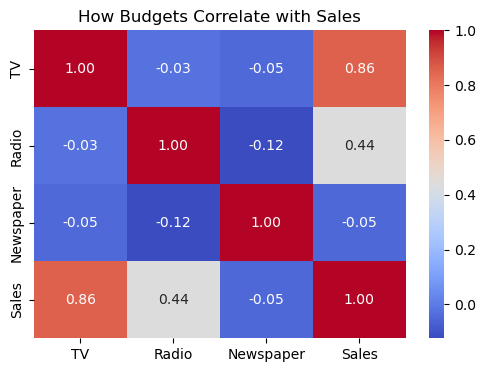

In [16]:
# 1. Check for missing / null values that could break the model
print("--- Check for Missing Values ---")
print(df.isnull().sum())

# 2. View statistical insights (Mean, Min, Max, etc.)
print("\n--- Summary Statistics ---")
print(df.describe())

# 3. Plot a correlation matrix map
plt.figure(figsize=(6, 4))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("How Budgets Correlate with Sales")
plt.show()


# Split Data into Training and Testing Sets

In [17]:
# Split the dataset into features (Inputs) and target variable (Output)
X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

# Split data: 80% used for model training, 20% held back for testing accuracy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Total dataset size:        {len(df)} rows")
print(f"Rows used for Training (80%): {len(X_train)} rows")
print(f"Rows saved for Testing (20%):  {len(X_test)} rows")


Total dataset size:        200 rows
Rows used for Training (80%): 160 rows
Rows saved for Testing (20%):  40 rows


# Initialize and Train the Machine Learning Model

In [18]:
# Initialize the model (using 100 decision trees to average predictions)
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model on our training data
model.fit(X_train, y_train)

print("Step 5 Complete: The machine learning model is now fully trained!")


Step 5 Complete: The machine learning model is now fully trained!


# Evaluate Model Performance Metrics

Mean Absolute Error (MAE): 0.91
Root Mean Squared Error (RMSE): 1.19
R-squared (R2) Accuracy Score: 0.9402 (Explains 94.0% of variations)


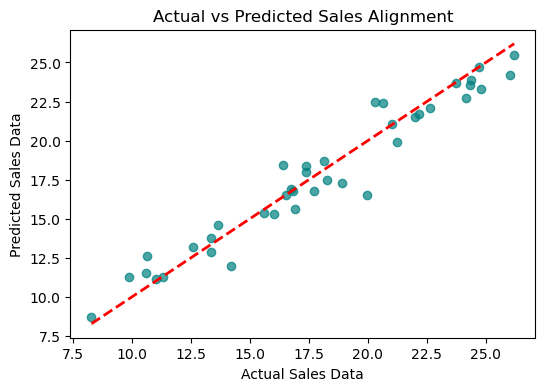

In [19]:
# Make predictions on test data
y_pred = model.predict(X_test)

# Calculate key evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2) Accuracy Score: {r2:.4f} (Explains {r2*100:.1f}% of variations)")

# Plot actual vs predicted sales
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, color="teal", alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
plt.xlabel("Actual Sales Data")
plt.ylabel("Predicted Sales Data")
plt.title("Actual vs Predicted Sales Alignment")
plt.show()


# Deploy Code for Live Predictions

In [20]:
# Define custom, hypothetical future budgets (in thousands of dollars)
future_tv_spend = 160.0
future_radio_spend = 35.0
future_newspaper_spend = 20.0

# Format the variables into a Pandas DataFrame matching the training layout
live_budget_plan = pd.DataFrame(
    {"TV": [future_tv_spend], "Radio": [future_radio_spend], "Newspaper": [future_newspaper_spend]}
)

# Run the live forecasting prediction
calculated_sales = model.predict(live_budget_plan)[0]

print("--- Future Campaign Forecast Results ---")
print(f"Proposed TV Spend:        ${future_tv_spend:,.2f}k")
print(f"Proposed Radio Spend:     ${future_radio_spend:,.2f}k")
print(f"Proposed Newspaper Spend: ${future_newspaper_spend:,.2f}k")
print(f"👉 Predicted Total Sales Output: {calculated_sales:.2f} units")


--- Future Campaign Forecast Results ---
Proposed TV Spend:        $160.00k
Proposed Radio Spend:     $35.00k
Proposed Newspaper Spend: $20.00k
👉 Predicted Total Sales Output: 19.14 units
